In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

In [ ]:
mnist=fetch_openml('mnist_784',version=1,as_frame=False)

In [ ]:
X=mnist.data
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print(X.dtype)
print(X.max())
print(X.min())

int64
255
0


In [ ]:
y=mnist.target.astype(int)
print(y)

[5 0 4 ... 4 5 6]


In [ ]:
y.dtype

dtype('int64')

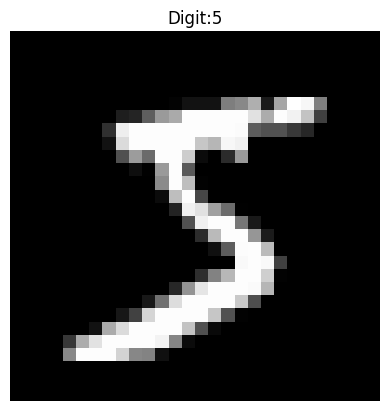

In [ ]:
plt.imshow(X[0].reshape(28,28),cmap='gray')
plt.title(f"Digit:{y[0]}")
plt.axis('off')
plt.show()

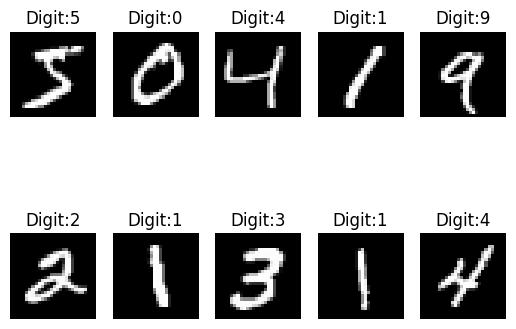

In [ ]:
fig,axes=plt.subplots(2,5)

for i,ax in enumerate(axes.ravel()):
  ax.imshow(X[i].reshape(28,28),cmap='gray')
  ax.set_title(f"Digit:{y[i]}")
  ax.axis('off')
plt.show()

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
mms=MinMaxScaler()
X_train_scaled=mms.fit_transform(X_train)
X_test_scaled=mms.transform(X_test)

**Finding Number of Components in PCA**

In [ ]:
# Method -1
pca_auto=PCA(n_components=0.95)
X_train_reduced=pca_auto.fit_transform(X_train_scaled)

print("Number of components chosen:",pca_auto.n_components_)
print("Total explained variance:",pca_auto.explained_variance_ratio_.sum())

Number of components chosen: 154
Total explained variance: 0.9503599437329574


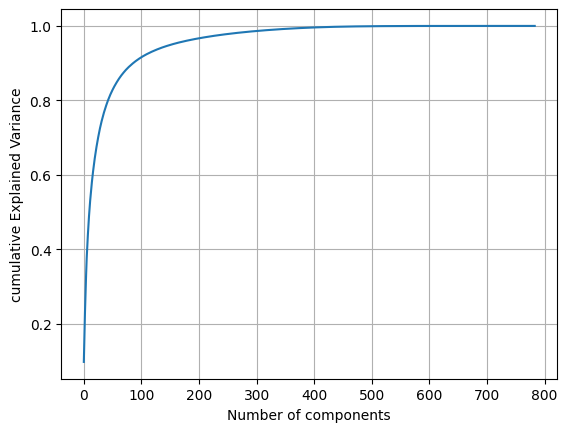

In [ ]:
# Method -2 ( Elbow curve)
pca_all=PCA()
pca_all.fit(X_train_scaled)

cumulative_variance=np.cumsum(pca_all.explained_variance_ratio_)

plt.plot(cumulative_variance)
plt.xlabel('Number of components')
plt.ylabel('cumulative Explained Variance')
plt.grid(True)
plt.show()

In [ ]:
X_test_reduced=pca_auto.transform(X_test_scaled)

In [ ]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [ ]:
models = {
    # 'SVC': SVC(probability=True), # Fix 1: Enabled probabilities
    #'DecisionTree': DecisionTreeClassifier(),
    #'GradientBoosting': GradientBoostingClassifier(),
    'RandomForest': RandomForestClassifier(),
    'XGBoost': XGBClassifier()
}

for name, model in models.items():
    print(f"\n{'='*40}\nEvaluating: {name}\n{'='*40}")

    # 1. Train the model on the reduced training data
    model.fit(X_train_reduced, y_train)

    # 2. Get standard predictions for the test set
    predictions = model.predict(X_test_reduced)

    # 3. Calculate basic metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    f1 = f1_score(y_test, predictions, average='weighted')

    # 4. Cross-validate on the TRAINING data (Fix 2)
    # Fix 3: We calculate OVR and OVO in a single run to save massive amounts of time
    cv_results = cross_validate(
        model,
        X_train_reduced,
        y_train,
        cv=5,
        scoring=['roc_auc_ovr', 'roc_auc_ovo']
    )

    # Extract the average scores from the cross-validation
    avg_roc_ovr = np.mean(cv_results['test_roc_auc_ovr'])
    avg_roc_ovo = np.mean(cv_results['test_roc_auc_ovo'])

    # 5. Print out the results in a clean, readable format (Fix 4)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")
    print(f"ROC (OVR): {avg_roc_ovr:.4f} | ROC (OVO): {avg_roc_ovo:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, predictions))


Evaluating: RandomForest
Accuracy:  0.9464
Precision: 0.9464 | Recall: 0.9464 | F1-Score: 0.9463
ROC (OVR): 0.9965 | ROC (OVO): 0.9965

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1381
           1       0.98      0.98      0.98      1575
           2       0.95      0.93      0.94      1398
           3       0.92      0.94      0.93      1428
           4       0.94      0.94      0.94      1365
           5       0.94      0.93      0.93      1263
           6       0.96      0.98      0.97      1375
           7       0.96      0.96      0.96      1459
           8       0.92      0.91      0.92      1365
           9       0.93      0.91      0.92      1391

    accuracy                           0.95     14000
   macro avg       0.95      0.95      0.95     14000
weighted avg       0.95      0.95      0.95     14000


Evaluating: XGBoost
Accuracy:  0.9634
Precision: 0.9634 | Recall: 0.9634 | F1-Sc

**Saving the script**

In [ ]:
import joblib

best_xgb=models['XGBoost']

best_xgb.save_model('best_xgb_model.json')
joblib.dump(pca_auto,'mnist_pca_transformer.pkl')

print("XGBoost and PCA successfully saved to disk!")

XGBoost and PCA successfully saved to disk!


**Real image Testing**

In [ ]:
import cv2
import numpy as np
import joblib
from xgboost import XGBClassifier

# 1. Load the Model and PCA
loaded_pca = joblib.load('mnist_pca_transformer.pkl')
loaded_xgb = XGBClassifier()
loaded_xgb.load_model('best_xgb_model.json')

def predict_uploaded_image(image_path, model, pca):
    # 2. Read the image in Grayscale mode
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Error: Could not load image. Check the file path.")
        return

    # 3. Invert colors if necessary!
    # MNIST is white-on-black. If your image is black-on-white (like a photo of paper),
    # you MUST invert it. If it's already white-on-black, comment this line out.
    img = cv2.bitwise_not(img)

    # 4. Resize to exactly 28x28 pixels
    img_resized = cv2.resize(img, (28, 28))

    # 5. Flatten the 28x28 grid into a 1D array of 784 pixels
    img_flattened = img_resized.flatten()

    # 6. Scale the data (just like we did for training)
    img_scaled = img_flattened / 255.0

    # 7. Reshape to match the expected input shape (1 sample, 784 features)
    img_ready = img_scaled.reshape(1, -1)

    # 8. Apply the PCA transformation
    img_pca = pca.transform(img_ready)

    # 9. Make the Prediction
    prediction = model.predict(img_pca)

    # XGBoost predict() sometimes returns an array of arrays, we just want the first number
    digit = prediction[0]
    print(f"\n---> The model predicts this digit is a: {digit} <---")

# --- Run it! ---
# Replace 'my_digit.png' with the actual path to your uploaded image
predict_uploaded_image('two.png', loaded_xgb, loaded_pca)


---> The model predicts this digit is a: 5 <---
